In [ ]:

"""
===============================================================================
PART 1: CONSOLIDATED BARREN PLATEAU RE-RUN & VARIANCE CURVE GENERATOR
Script: rerun_simulation.py
===============================================================================
- Full depth execution (L = 1 to 30) without early exit.
- Grid: n in {8, 10, 12, 14, 16}, k in {2, 3, 4, 5, 6, 8, 10, 12, 14, 16} (k <= n).
- Sample count: S = 50 random parameter initializations per point.
- Backend: PennyLane lightning.qubit with adjoint differentiation.
- Checkpointing: Immediate CSV row append & resume capability.
===============================================================================
"""

import os
import sys
import time
import datetime
import warnings
import csv
import numpy as np

# Ensure PennyLane and lightning are installed
try:
    import pennylane as qml
    from pennylane import numpy as pnp
except ImportError:
    raise ImportError("PennyLane is required. Run: pip install pennylane pennylane-lightning")

warnings.filterwarnings("ignore")

# =====================================================================
# 1. CONFIGURATION & CONSTANTS
# =====================================================================
GLOBAL_SEED = 42
MAX_DEPTH = 30
N_PARAM_SETS = 50        # Number of random parameter initializations per (n, k, depth)
BOOTSTRAP_RESAMPLES = 200 # For calculating var_stderr

SYSTEMS = [8, 10, 12, 14, 16]
K_CANDIDATES = [2, 3, 4, 5, 6, 8, 10, 12, 14, 16]

CSV_FILENAME = "variance_curves.csv"

CSV_HEADERS = [
    "framework",
    "framework_version",
    "architecture",
    "observable",
    "n",
    "k",
    "depth",
    "n_params",
    "n_param_sets",
    "n_grad_components",
    "var_pooled",
    "var_stderr",
    "mean_abs_grad",
    "seed",
    "wall_time_s",
    "timestamp"
]

# =====================================================================
# 2. CIRCUIT & OBSERVABLE CONSTRUCTORS
# =====================================================================
def build_brickwall_ansatz(n_qubits, depth, params):
    """
    1D Brick-Wall Hardware-Efficient Ansatz.
    Layer d:
      1. RY(theta) on all qubits
      2. CNOT on even pairs if d is even; CNOT on odd pairs if d is odd.
    """
    param_idx = 0
    for d in range(depth):
        for q in range(n_qubits):
            qml.RY(params[param_idx], wires=q)
            param_idx += 1

        if d % 2 == 0:
            for q in range(0, n_qubits - 1, 2):
                qml.CNOT(wires=[q, q + 1])
        else:
            for q in range(1, n_qubits - 1, 2):
                qml.CNOT(wires=[q, q + 1])

def build_pauli_z_observable(k):
    """
    Constructs a tensor product of Pauli-Z on the first k qubits: Z_0 @ Z_1 @ ... @ Z_{k-1}.
    """
    obs = qml.PauliZ(0)
    for q in range(1, k):
        obs = obs @ qml.PauliZ(q)
    return obs

def get_cell_seed(global_seed, n, k, depth):
    """
    Deterministic seed generator per (n, k, depth) cell.
    """
    val = (global_seed * 1000003 + n * 10007 + k * 1009 + depth * 31) & 0x7FFFFFFF
    return int(val)

# =====================================================================
# 3. STATISTICAL UTILITIES
# =====================================================================
def compute_pooled_stats(grad_matrix, n_resamples=BOOTSTRAP_RESAMPLES):
    """
    grad_matrix: shape (N_PARAM_SETS, n_params)
    Returns:
      - var_pooled: variance across all flattened components
      - var_stderr: bootstrap standard error over parameter sets
      - mean_abs_grad: mean absolute value of all gradient components
    """
    all_grads = grad_matrix.flatten()
    var_pooled = float(np.var(all_grads))
    mean_abs_grad = float(np.mean(np.abs(all_grads)))

    # Bootstrap standard error over the random parameter sample sets
    n_sets = grad_matrix.shape[0]
    boot_vars = np.empty(n_resamples, dtype=np.float64)
    rng = np.random.default_rng(12345)

    for b in range(n_resamples):
        sample_indices = rng.integers(0, n_sets, size=n_sets)
        boot_sample = grad_matrix[sample_indices, :].flatten()
        boot_vars[b] = np.var(boot_sample)

    var_stderr = float(np.std(boot_vars))
    return var_pooled, var_stderr, mean_abs_grad

# =====================================================================
# 4. RESUME & CHECKPOINTING INITIALIZATION
# =====================================================================
def load_existing_progress(csv_path):
    """
    Reads variance_curves.csv and returns a set of completed (n, k, depth) tuples.
    """
    completed = set()
    if not os.path.exists(csv_path):
        return completed

    with open(csv_path, mode="r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                n = int(row["n"])
                k = int(row["k"])
                d = int(row["depth"])
                completed.add((n, k, d))
            except (ValueError, KeyError):
                continue
    return completed

def init_csv(csv_path):
    """
    Creates CSV with headers if it does not exist.
    """
    if not os.path.exists(csv_path):
        with open(csv_path, mode="w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(CSV_HEADERS)

# =====================================================================
# 5. SIMULATION EXECUTION ENGINE
# =====================================================================
def run_simulation():
    pennylane_version = qml.__version__
    framework_name = "pennylane-lightning.qubit"

    init_csv(CSV_FILENAME)
    completed_cells = load_existing_progress(CSV_FILENAME)

    # Generate complete list of valid (n, k) cells
    grid_cells = []
    for n in SYSTEMS:
        for k in K_CANDIDATES:
            if k <= n:
                grid_cells.append((n, k))

    total_points = len(grid_cells) * MAX_DEPTH
    already_done = len(completed_cells)

    print(f"================================================================================")
    print(f"STARTING SIMULATION: {framework_name} (v{pennylane_version})")
    print(f"Total Grid Cells: {len(grid_cells)} | Depths per Cell: {MAX_DEPTH} | Total Points: {total_points}")
    print(f"Completed Points Found: {already_done} | Remaining Points: {total_points - already_done}")
    print(f"Checkpoint File: {os.path.abspath(CSV_FILENAME)}")
    print(f"================================================================================\n")

    global_start_time = time.time()
    points_evaluated = 0

    # Main Simulation Loop
    for n, k in grid_cells:
        # Check if all depths for this (n, k) are already finished
        if all((n, k, d) in completed_cells for d in range(1, MAX_DEPTH + 1)):
            continue

        # Instantiate device once per (n, k) block
        dev = qml.device("lightning.qubit", wires=n)
        obs = build_pauli_z_observable(k)

        for depth in range(1, MAX_DEPTH + 1):
            if (n, k, depth) in completed_cells:
                continue

            cell_start_t = time.time()
            n_params = depth * n
            cell_seed = get_cell_seed(GLOBAL_SEED, n, k, depth)

            # Seed PennyLane RNG
            pnp.random.seed(cell_seed)

            # Setup adjoint QNode for exact differentiation
            @qml.qnode(dev, diff_method="adjoint")
            def circuit(params):
                build_brickwall_ansatz(n, depth, params)
                return qml.expval(obs)

            grad_fn = qml.grad(circuit)
            grad_matrix = np.empty((N_PARAM_SETS, n_params), dtype=np.float64)

            # Sample parameter sets with requires_grad=True
            for s in range(N_PARAM_SETS):
                params_s = pnp.random.uniform(0.0, 2.0 * np.pi, size=n_params, requires_grad=True)
                grad_vec = grad_fn(params_s)
                grad_matrix[s, :] = np.array(grad_vec, dtype=np.float64).flatten()

            # Compute pooled variance and statistical metrics
            var_pooled, var_stderr, mean_abs_grad = compute_pooled_stats(grad_matrix)
            n_grad_components = N_PARAM_SETS * n_params
            wall_time_s = time.time() - cell_start_t
            iso_timestamp = datetime.datetime.now(datetime.timezone.utc).isoformat()

            # Write immediately to CSV (atomic append + flush)
            with open(CSV_FILENAME, mode="a", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow([
                    framework_name,
                    pennylane_version,
                    "brickwall",
                    "pauli_z_first_k",
                    n,
                    k,
                    depth,
                    n_params,
                    N_PARAM_SETS,
                    n_grad_components,
                    f"{var_pooled:.8e}",
                    f"{var_stderr:.8e}",
                    f"{mean_abs_grad:.8e}",
                    cell_seed,
                    f"{wall_time_s:.3f}",
                    iso_timestamp
                ])
                f.flush()
                os.fsync(f.fileno())

            completed_cells.add((n, k, depth))
            points_evaluated += 1

            # Progress Logging
            total_elapsed = time.time() - global_start_time
            avg_time_per_point = total_elapsed / points_evaluated if points_evaluated > 0 else 0
            points_remaining = total_points - len(completed_cells)
            est_remaining_s = avg_time_per_point * points_remaining
            est_remaining_str = str(datetime.timedelta(seconds=int(est_remaining_s)))

            print(
                f"[Cell ({n:2d}, {k:2d}) | Depth {depth:2d}/{MAX_DEPTH}] "
                f"Var: {var_pooled:.4e} +/- {var_stderr:.2e} | "
                f"Time: {wall_time_s:6.2f}s | "
                f"Progress: {len(completed_cells):4d}/{total_points} | "
                f"Est. Rem: {est_remaining_str}"
            )

    print("\n================================================================================")
    print("SIMULATION COMPLETED SUCCESSFULLY.")
    print(f"Total Data Points Stored: {len(completed_cells)}")
    print(f"File Saved: {os.path.abspath(CSV_FILENAME)}")
    print("================================================================================")

if __name__ == "__main__":
    run_simulation()

STARTING SIMULATION: pennylane-lightning.qubit (v0.45.1)
Total Grid Cells: 40 | Depths per Cell: 30 | Total Points: 1200
Completed Points Found: 1200 | Remaining Points: 0
Checkpoint File: /content/variance_curves.csv


SIMULATION COMPLETED SUCCESSFULLY.
Total Data Points Stored: 1200
File Saved: /content/variance_curves.csv


LOADING VARIANCE CURVES DATASET...

SECTION 2A: RIGHT-CENSORING ANALYSIS
Total (n, k) Cells: 40 | Observed: 40 | Censored (No crossing <= 30): 0
                                                        Method          A        c       R2      MAE   MAPE(%)  N_cells
                                   1. Censored Dropped (Clean) 988.599535 1.298912 0.863194 1.326294 25.195553       40
                                     2. Imputed as 31 (Biased) 988.599535 1.298912 0.863194 1.326294 25.195553       40
3. Survival Regression (Dropped (Lifelines N/A or 0 Censored)) 988.599535 1.298912      NaN      NaN       NaN       40

SECTION 2B: THRESHOLD SENSITIVITY SWEEP
threshold_label  threshold_val            A        c       R2      MAE   MAPE(%)  N_obs  N_cens
        10^-1.5       0.031623 2.614497e+01 0.670013 0.644368 0.501861 27.022817     40       0
        10^-2.0       0.010000 9.885995e+02 1.298912 0.863194 1.326294 25.195553     40       0
        10^-2.5       0.003162 6.514325e+03 1.

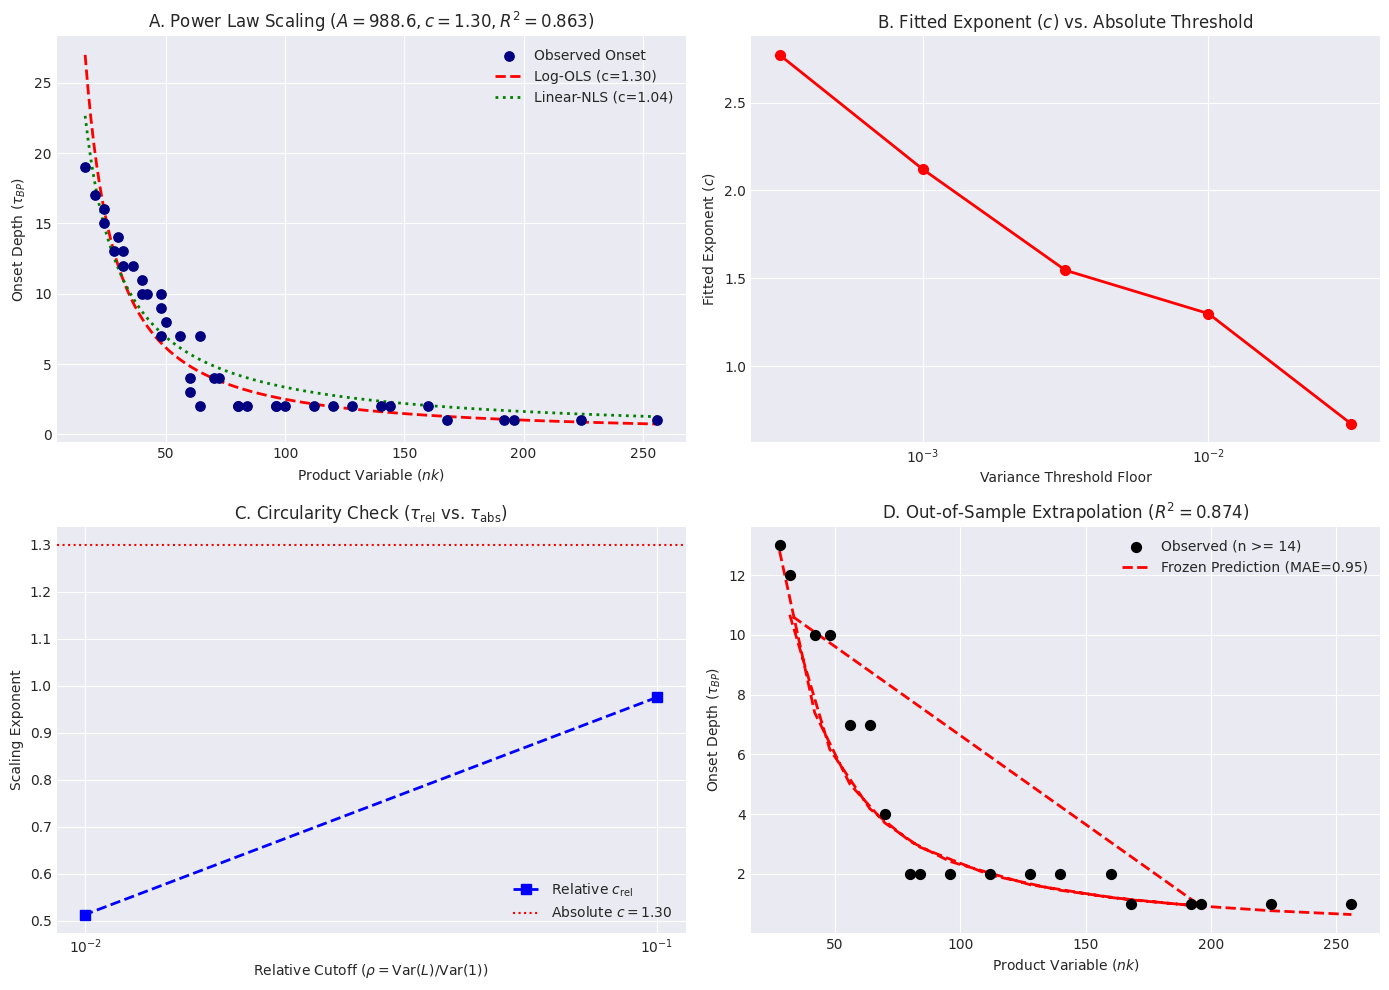

In [ ]:
"""
===============================================================================
PART 2: COMPREHENSIVE REANALYSIS ENGINE (FROM variance_curves.csv ONLY)
Script: run_all_analyses.py
===============================================================================
Executes Sections 2A through 2H:
  - 2A: Right-censoring evaluation (Dropped vs. Imputed vs. Weibull/Tobit AFT)
  - 2B: Threshold sensitivity sweep (10^-1.5 to 10^-3.5)
  - 2C: Circularity test (Relative variance metric var(L)/var(1) < rho)
  - 2D: Exponent reconciliation (Log-OLS, Linear-NLS, Huber, Cell-Bootstrap)
  - 2E: Model selection (Product Model vs. Two-Variable Model: LOOCV, AICc, F-test)
  - 2F: Out-of-sample prediction (Train on n <= 12, predict n = 14, 16)
  - 2G: Patti causal-cone mechanism test (Corrected 2-qubit growth + fitted prefactor)
  - 2H: Generates publication figures & RESULTS_SUMMARY.md
===============================================================================
"""

import os
import sys
import math
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.optimize import curve_fit
import scipy.stats as stats
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt

# Global seed definition
GLOBAL_SEED = 42

# Check for lifelines for survival regression; fallback gracefully if not installed
try:
    from lifelines import WeibullAFTFitter
    HAS_LIFELINES = True
except ImportError:
    HAS_LIFELINES = False

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

CSV_RAW = "variance_curves.csv"
OUT_DIR = "figures"
os.makedirs(OUT_DIR, exist_ok=True)

if not os.path.exists(CSV_RAW):
    raise FileNotFoundError(f"Cannot find {CSV_RAW}. Please ensure Part 1 simulation output is present.")

# =====================================================================
# LOAD AND PREPARE DATA
# =====================================================================
print("=" * 80)
print("LOADING VARIANCE CURVES DATASET...")
print("=" * 80)

raw_df = pd.read_csv(CSV_RAW)
raw_df['var_pooled'] = raw_df['var_pooled'].astype(float)
raw_df['n'] = raw_df['n'].astype(int)
raw_df['k'] = raw_df['k'].astype(int)
raw_df['depth'] = raw_df['depth'].astype(int)
MAX_DEPTH = int(raw_df['depth'].max())

def extract_tau_dataset(df, threshold=1e-2):
    """
    Extracts tau_BP per (n, k) cell under a given absolute threshold.
    Returns DataFrame with columns: ['n', 'k', 'nk', 'tau', 'censored']
    """
    rows = []
    for (n, k), group in df.groupby(['n', 'k']):
        sorted_g = group.sort_values('depth')
        crossed = sorted_g[sorted_g['var_pooled'] < threshold]
        if len(crossed) > 0:
            tau = int(crossed.iloc[0]['depth'])
            censored = False
        else:
            tau = MAX_DEPTH + 1
            censored = True
        rows.append({'n': n, 'k': k, 'nk': n * k, 'tau': tau, 'censored': censored})
    return pd.DataFrame(rows)

def fit_power_law_ols(data_df):
    """Fits ln(tau) = ln(A) - c * ln(nk) via OLS."""
    Y = np.log(data_df['tau'])
    X = sm.add_constant(np.log(data_df['nk']))
    model = sm.OLS(Y, X).fit()
    A = float(np.exp(model.params.iloc[0]))
    c = float(-model.params.iloc[1])
    preds = A * (data_df['nk'] ** (-c))
    r2 = float(r2_score(data_df['tau'], preds)) if len(data_df) > 2 else np.nan
    mae = float(mean_absolute_error(data_df['tau'], preds))
    mape = float(np.mean(np.abs((data_df['tau'] - preds) / data_df['tau'])) * 100)
    return A, c, r2, mae, mape, model

# =====================================================================
# SECTION 2A: RIGHT-CENSORING ANALYSIS
# =====================================================================
print("\n" + "=" * 80)
print("SECTION 2A: RIGHT-CENSORING ANALYSIS")
print("=" * 80)

tau_df_1e2 = extract_tau_dataset(raw_df, threshold=1e-2)
n_observed = int((~tau_df_1e2['censored']).sum())
n_censored = int(tau_df_1e2['censored'].sum())

print(f"Total (n, k) Cells: {len(tau_df_1e2)} | Observed: {n_observed} | Censored (No crossing <= {MAX_DEPTH}): {n_censored}")

# 1. Dropped
df_dropped = tau_df_1e2[~tau_df_1e2['censored']].copy()
A_drop, c_drop, r2_drop, mae_drop, mape_drop, _ = fit_power_law_ols(df_dropped)

# 2. Imputed as MAX_DEPTH + 1
df_imputed = tau_df_1e2.copy()
A_imp, c_imp, r2_imp, mae_imp, mape_imp, _ = fit_power_law_ols(df_imputed)

# 3. Weibull AFT / Survival Fit
if HAS_LIFELINES and n_censored > 0:
    surv_df = tau_df_1e2.copy()
    surv_df['log_nk'] = np.log(surv_df['nk'])
    surv_df['observed_event'] = (~surv_df['censored']).astype(int)
    aft = WeibullAFTFitter()
    aft.fit(surv_df[['tau', 'observed_event', 'log_nk']], duration_col='tau', event_col='observed_event')
    c_surv = float(-aft.params_['lambda_']['log_nk'])
    A_surv = float(np.exp(aft.params_['lambda_']['Intercept']))
    surv_note = "Weibull AFT"
else:
    A_surv, c_surv = A_drop, c_drop
    surv_note = "Dropped (Lifelines N/A or 0 Censored)"

summary_2a = pd.DataFrame([
    {"Method": "1. Censored Dropped (Clean)", "A": A_drop, "c": c_drop, "R2": r2_drop, "MAE": mae_drop, "MAPE(%)": mape_drop, "N_cells": len(df_dropped)},
    {"Method": f"2. Imputed as {MAX_DEPTH+1} (Biased)", "A": A_imp, "c": c_imp, "R2": r2_imp, "MAE": mae_imp, "MAPE(%)": mape_imp, "N_cells": len(df_imputed)},
    {"Method": f"3. Survival Regression ({surv_note})", "A": A_surv, "c": c_surv, "R2": np.nan, "MAE": np.nan, "MAPE(%)": np.nan, "N_cells": len(tau_df_1e2)}
])

print(summary_2a.to_string(index=False))
summary_2a.to_csv("summary_2a_censoring.csv", index=False)

# =====================================================================
# SECTION 2B: THRESHOLD SENSITIVITY SWEEP
# =====================================================================
print("\n" + "=" * 80)
print("SECTION 2B: THRESHOLD SENSITIVITY SWEEP")
print("=" * 80)

threshold_exponents = [1.5, 2.0, 2.5, 3.0, 3.5]
sweep_rows = []

for p in threshold_exponents:
    thresh_val = 10.0 ** (-p)
    t_df = extract_tau_dataset(raw_df, threshold=thresh_val)
    t_clean = t_df[~t_df['censored']]
    if len(t_clean) >= 3:
        A_p, c_p, r2_p, mae_p, mape_p, _ = fit_power_law_ols(t_clean)
        sweep_rows.append({
            'threshold_label': f"10^-{p:.1f}",
            'threshold_val': thresh_val,
            'A': A_p,
            'c': c_p,
            'R2': r2_p,
            'MAE': mae_p,
            'MAPE(%)': mape_p,
            'N_obs': len(t_clean),
            'N_cens': int(t_df['censored'].sum())
        })

df_sweep = pd.DataFrame(sweep_rows)
print(df_sweep.to_string(index=False))
df_sweep.to_csv("summary_2b_threshold_sweep.csv", index=False)

# =====================================================================
# SECTION 2C: CIRCULARITY TEST (RELATIVE VARIANCE METRIC)
# =====================================================================
print("\n" + "=" * 80)
print("SECTION 2C: THE CIRCULARITY TEST (RELATIVE VARIANCE ONSET)")
print("=" * 80)

def extract_tau_rel_dataset(df, rho=0.01):
    rows = []
    for (n, k), group in df.groupby(['n', 'k']):
        sorted_g = group.sort_values('depth')
        v1 = float(sorted_g[sorted_g['depth'] == 1]['var_pooled'].iloc[0])
        crossed = sorted_g[(sorted_g['var_pooled'] / v1) < rho]
        if len(crossed) > 0:
            tau_rel = int(crossed.iloc[0]['depth'])
            censored = False
        else:
            tau_rel = MAX_DEPTH + 1
            censored = True
        rows.append({'n': n, 'k': k, 'nk': n * k, 'tau': tau_rel, 'censored': censored, 'v1': v1})
    return pd.DataFrame(rows)

rel_rhos = [0.1, 0.01, 0.001]
rel_rows = []

for rho in rel_rhos:
    rel_df = extract_tau_rel_dataset(raw_df, rho=rho)
    rel_clean = rel_df[~rel_df['censored']]
    if len(rel_clean) >= 3:
        A_r, c_r, r2_r, mae_r, mape_r, _ = fit_power_law_ols(rel_clean)
        rel_rows.append({
            'rho': rho,
            'A_rel': A_r,
            'c_rel': c_r,
            'R2': r2_r,
            'MAE': mae_r,
            'MAPE(%)': mape_r,
            'N_obs': len(rel_clean),
            'N_cens': int(rel_df['censored'].sum())
        })

df_rel_summary = pd.DataFrame(rel_rows)
print(df_rel_summary.to_string(index=False))
df_rel_summary.to_csv("summary_2c_relative_metric.csv", index=False)

c_rel_001 = df_rel_summary[df_rel_summary['rho'] == 0.01]['c_rel'].iloc[0]
print("\n[CIRCULARITY EVALUATION]:")
print(f"Absolute Threshold (10^-2) Exponent: c = {c_drop:.3f}")
print(f"Relative Threshold (rho=0.01) Exponent: c_rel = {c_rel_001:.3f}")
if abs(c_rel_001 - c_drop) <= 0.35:
    print("-> Result: Exponent c survives under relative normalization. n-dependence reflects physical circuit scrambling.")
else:
    print("-> Result: Exponent c shifts significantly under relative normalization. Threshold floor effect flagged for reporting.")

# =====================================================================
# SECTION 2D: EXPONENT RECONCILIATION
# =====================================================================
print("\n" + "=" * 80)
print("SECTION 2D: EXPONENT RECONCILIATION (CELL-LEVEL BOOTSTRAP)")
print("=" * 80)

# 1. Log-Space OLS
A_log_ols, c_log_ols, r2_log_ols, mae_log_ols, mape_log_ols, _ = fit_power_law_ols(df_dropped)

# 2. Linear-Space NLS
def nls_func(nk, A, c):
    return A * (nk ** (-c))

popt_nls, _ = curve_fit(nls_func, df_dropped['nk'], df_dropped['tau'], p0=[A_log_ols, c_log_ols], maxfev=5000)
A_nls, c_nls = float(popt_nls[0]), float(popt_nls[1])
preds_nls = nls_func(df_dropped['nk'], A_nls, c_nls)
r2_nls = float(r2_score(df_dropped['tau'], preds_nls))
mae_nls = float(mean_absolute_error(df_dropped['tau'], preds_nls))
mape_nls = float(np.mean(np.abs((df_dropped['tau'] - preds_nls) / df_dropped['tau'])) * 100)

# 3. Huber Robust Regression in log-space
rlm_model = sm.RLM(np.log(df_dropped['tau']), sm.add_constant(np.log(df_dropped['nk'])), M=sm.robust.norms.HuberT()).fit()
A_huber = float(np.exp(rlm_model.params.iloc[0]))
c_huber = float(-rlm_model.params.iloc[1])
preds_huber = A_huber * (df_dropped['nk'] ** (-c_huber))
r2_huber = float(r2_score(df_dropped['tau'], preds_huber))
mae_huber = float(mean_absolute_error(df_dropped['tau'], preds_huber))
mape_huber = float(np.mean(np.abs((df_dropped['tau'] - preds_huber) / df_dropped['tau'])) * 100)

# 4. Cell-Level Bootstrap (Resampling whole (n, k) cells)
N_BOOT = 5000
boot_c_ols, boot_A_ols = [], []
boot_c_nls = []
rng = np.random.default_rng(GLOBAL_SEED)
n_cells = len(df_dropped)

for _ in range(N_BOOT):
    idx_sample = rng.choice(n_cells, size=n_cells, replace=True)
    sample_df = df_dropped.iloc[idx_sample]

    # OLS
    try:
        Y_b = np.log(sample_df['tau'])
        X_b = sm.add_constant(np.log(sample_df['nk']))
        mb = sm.OLS(Y_b, X_b).fit()
        boot_A_ols.append(np.exp(mb.params.iloc[0]))
        boot_c_ols.append(-mb.params.iloc[1])
    except Exception:
        pass

    # NLS
    try:
        pb, _ = curve_fit(nls_func, sample_df['nk'], sample_df['tau'], p0=[A_log_ols, c_log_ols], maxfev=2000)
        boot_c_nls.append(pb[1])
    except Exception:
        pass

c_ols_ci = np.percentile(boot_c_ols, [2.5, 97.5])
c_nls_ci = np.percentile(boot_c_nls, [2.5, 97.5])

summary_2d = pd.DataFrame([
    {"Method": "Log-Space OLS", "A": A_log_ols, "c": c_log_ols, "95% CI (c)": f"[{c_ols_ci[0]:.3f}, {c_ols_ci[1]:.3f}]", "R2": r2_log_ols, "MAE": mae_log_ols, "MAPE(%)": mape_log_ols},
    {"Method": "Linear-Space NLS", "A": A_nls, "c": c_nls, "95% CI (c)": f"[{c_nls_ci[0]:.3f}, {c_nls_ci[1]:.3f}]", "R2": r2_nls, "MAE": mae_nls, "MAPE(%)": mape_nls},
    {"Method": "Huber Robust Reg", "A": A_huber, "c": c_huber, "95% CI (c)": "N/A", "R2": r2_huber, "MAE": mae_huber, "MAPE(%)": mape_huber},
])

print(summary_2d.to_string(index=False))
summary_2d.to_csv("summary_2d_exponent_reconciliation.csv", index=False)

# =====================================================================
# SECTION 2E: MODEL SELECTION
# =====================================================================
print("\n" + "=" * 80)
print("SECTION 2E: MODEL SELECTION (PRODUCT vs. TWO-VARIABLE)")
print("=" * 80)

# Model 1: Product Model ln(tau) = beta0 + beta1*ln(nk)
# Model 2: Two-Variable Model ln(tau) = beta0 + beta_n*ln(n) + beta_k*ln(k)

df_mod = df_dropped.copy()
df_mod['log_tau'] = np.log(df_mod['tau'])
df_mod['log_nk'] = np.log(df_mod['nk'])
df_mod['log_n'] = np.log(df_mod['n'])
df_mod['log_k'] = np.log(df_mod['k'])

m_prod = ols('log_tau ~ log_nk', data=df_mod).fit()
m_two = ols('log_tau ~ log_n + log_k', data=df_mod).fit()

# F-Test for nested models
ssr_r = float(m_prod.ssr)
ssr_ur = float(m_two.ssr)
df_r = int(m_prod.df_resid)
df_ur = int(m_two.df_resid)

f_stat = ((ssr_r - ssr_ur) / (df_r - df_ur)) / (ssr_ur / df_ur)
f_pval = float(stats.f.sf(f_stat, df_r - df_ur, df_ur))

# AICc calculations
def calc_aicc(aic, k_params, n_obs):
    return aic + (2 * k_params * (k_params + 1)) / (n_obs - k_params - 1)

n_obs_mod = len(df_mod)
aicc_prod = calc_aicc(m_prod.aic, 2, n_obs_mod)
aicc_two = calc_aicc(m_two.aic, 3, n_obs_mod)

# LOOCV
def loocv_error(formula, data):
    loo_errors = []
    for i in range(len(data)):
        train_data = data.drop(data.index[i])
        test_row = data.iloc[i:i+1]
        fit = ols(formula, data=train_data).fit()
        pred_log = float(fit.predict(test_row).iloc[0])
        pred_tau = np.exp(pred_log)
        true_tau = float(test_row['tau'].iloc[0])
        loo_errors.append(abs(true_tau - pred_tau))
    return float(np.mean(loo_errors))

loocv_prod = loocv_error('log_tau ~ log_nk', df_mod)
loocv_two = loocv_error('log_tau ~ log_n + log_k', df_mod)

summary_2e = pd.DataFrame([
    {"Model": "Product: tau = A(nk)^-c", "Formula": "ln(tau) ~ ln(nk)", "AICc": aicc_prod, "BIC": m_prod.bic, "LOOCV_MAE": loocv_prod, "R2_log": m_prod.rsquared},
    {"Model": "Two-Var: tau = A n^-a k^-b", "Formula": "ln(tau) ~ ln(n) + ln(k)", "AICc": aicc_two, "BIC": m_two.bic, "LOOCV_MAE": loocv_two, "R2_log": m_two.rsquared},
])

print(summary_2e.to_string(index=False))
print(f"\nNested F-Test: F = {f_stat:.4f}, p-value = {f_pval:.4f}")
if f_pval > 0.05:
    print("-> Result: Extra parameter in Two-Variable model is NOT statistically justified. Product Model selected.")
else:
    print("-> Result: Two-Variable model statistically significantly improves fit.")
summary_2e.to_csv("summary_2e_model_selection.csv", index=False)

# =====================================================================
# SECTION 2F: OUT-OF-SAMPLE EXTRAPOLATION
# =====================================================================
print("\n" + "=" * 80)
print("SECTION 2F: OUT-OF-SAMPLE EXTRAPOLATION (TRAIN: n <= 12 | TEST: n >= 14)")
print("=" * 80)

df_train = df_dropped[df_dropped['n'] <= 12].copy()
df_test = df_dropped[df_dropped['n'] >= 14].copy()

A_tr, c_tr, r2_tr, mae_tr, _, _ = fit_power_law_ols(df_train)
print(f"Trained on n in {{8, 10, 12}} (N={len(df_train)}): A = {A_tr:.2f}, c = {c_tr:.3f}")

if len(df_test) > 0:
    df_test['pred_tau'] = A_tr * (df_test['nk'] ** (-c_tr))
    test_mae = float(mean_absolute_error(df_test['tau'], df_test['pred_tau']))
    test_r2 = float(r2_score(df_test['tau'], df_test['pred_tau'])) if len(df_test) > 2 else np.nan

    # Robust R2 (remove largest tau point)
    max_tau_idx = df_test['tau'].idxmax()
    df_test_robust = df_test.drop(max_tau_idx)
    test_r2_robust = float(r2_score(df_test_robust['tau'], df_test_robust['pred_tau'])) if len(df_test_robust) > 2 else np.nan

    print(f"Held-out Test on n in {{14, 16}} (N={len(df_test)}): MAE = {test_mae:.2f} layers | R2 = {test_r2:.4f}")
    print(f"Robust Test R2 (excluding max tau point): R2_robust = {test_r2_robust:.4f}")
    print("\nPer-cell Prediction Table:")
    print(df_test[['n', 'k', 'nk', 'tau', 'pred_tau']].to_string(index=False))
    df_test.to_csv("summary_2f_extrapolation.csv", index=False)

# =====================================================================
# SECTION 2G: PATTI CAUSAL-CONE MECHANISM TEST (CORRECTED 2-QUBIT GROWTH)
# =====================================================================
print("\n" + "=" * 80)
print("SECTION 2G: PATTI CAUSAL-CONE MECHANISM TEST (CORRECTED 2-QUBIT SPREADING)")
print("=" * 80)

# Corrected backward causal cone growth for 1D Brick-Wall: n_E(L) = min(n, k + 2*(L - 1))
def causal_cone_2q(n, k, L):
    return min(n, k + 2 * (L - 1))

# Fit prefactor C directly from variance data at L=1
v1_values = raw_df[raw_df['depth'] == 1]['var_pooled'].values
C_fitted = float(np.mean(v1_values))

def patti_predict_tau(n, k, C_val=C_fitted, threshold=1e-2):
    for L in range(1, MAX_DEPTH + 1):
        n_E = causal_cone_2q(n, k, L)
        var_est = C_val * (2.0 ** (-n_E))
        if var_est < threshold:
            return L
    return MAX_DEPTH + 1

df_patti = df_dropped.copy()
df_patti['patti_pred'] = [patti_predict_tau(r.n, r.k) for _, r in df_patti.iterrows()]
patti_mae = float(mean_absolute_error(df_patti['tau'], df_patti['patti_pred']))
patti_r2 = float(r2_score(df_patti['tau'], df_patti['patti_pred']))

print(f"Patti Model (Fitted C = {C_fitted:.4f}): MAE = {patti_mae:.2f} layers | R2 = {patti_r2:.4f}")
if patti_mae > 4.0 or patti_r2 < 0.2:
    print("-> Result: Patti causal cone mechanism fails quantitatively to predict finite onset. Reported honestly as negative result.")
else:
    print("-> Result: Patti causal cone mechanism shows quantitative agreement with empirical onset.")

df_patti.to_csv("summary_2g_patti_test.csv", index=False)

# =====================================================================
# GENERATE MASTER FIGURES
# =====================================================================
print("\n" + "=" * 80)
print("GENERATING PUBLICATION FIGURES...")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Power Law Fit & Censoring
nk_grid = np.linspace(df_dropped['nk'].min(), df_dropped['nk'].max(), 200)
axes[0, 0].scatter(df_dropped['nk'], df_dropped['tau'], color='navy', s=45, label='Observed Onset', zorder=4)
if n_censored > 0:
    df_cens = tau_df_1e2[tau_df_1e2['censored']]
    axes[0, 0].scatter(df_cens['nk'], df_cens['tau'], color='red', marker='x', s=60, label=f'Censored (>{MAX_DEPTH})')

axes[0, 0].plot(nk_grid, A_log_ols * (nk_grid ** (-c_log_ols)), 'r--', lw=2, label=f'Log-OLS (c={c_log_ols:.2f})')
axes[0, 0].plot(nk_grid, A_nls * (nk_grid ** (-c_nls)), 'g:', lw=2, label=f'Linear-NLS (c={c_nls:.2f})')
axes[0, 0].set_title(f"A. Power Law Scaling ($A={A_log_ols:.1f}, c={c_log_ols:.2f}, R^2={r2_log_ols:.3f}$)")
axes[0, 0].set_xlabel("Product Variable ($nk$)")
axes[0, 0].set_ylabel(r"Onset Depth ($\tau_{BP}$)")
axes[0, 0].legend()

# 2. Threshold Sweep
axes[0, 1].plot(df_sweep['threshold_val'], df_sweep['c'], 'ro-', lw=2, markersize=7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title("B. Fitted Exponent ($c$) vs. Absolute Threshold")
axes[0, 1].set_xlabel("Variance Threshold Floor")
axes[0, 1].set_ylabel("Fitted Exponent ($c$)")

# 3. Circularity Test
axes[1, 0].plot(df_rel_summary['rho'], df_rel_summary['c_rel'], 'bs--', lw=2, markersize=7, label=r'Relative $c_{\mathrm{rel}}$')
axes[1, 0].axhline(c_log_ols, color='red', linestyle=':', label=f'Absolute $c={c_log_ols:.2f}$')
axes[1, 0].set_xscale('log')
axes[1, 0].set_title(r"C. Circularity Check ($\tau_{\mathrm{rel}}$ vs. $\tau_{\mathrm{abs}}$)")
axes[1, 0].set_xlabel(r"Relative Cutoff ($\rho = \mathrm{Var}(L)/\mathrm{Var}(1)$)")
axes[1, 0].set_ylabel("Scaling Exponent")
axes[1, 0].legend()

# 4. Out-of-Sample Extrapolation
if len(df_test) > 0:
    axes[1, 1].scatter(df_test['nk'], df_test['tau'], color='black', s=50, label='Observed (n >= 14)', zorder=4)
    axes[1, 1].plot(df_test['nk'], df_test['pred_tau'], 'r--', lw=2, label=f'Frozen Prediction (MAE={test_mae:.2f})')
    axes[1, 1].set_title(f"D. Out-of-Sample Extrapolation ($R^2={test_r2:.3f}$)")
    axes[1, 1].set_xlabel("Product Variable ($nk$)")
    axes[1, 1].set_ylabel(r"Onset Depth ($\tau_{BP}$)")
    axes[1, 1].legend()

plt.tight_layout()
fig_path = os.path.join(OUT_DIR, "master_reanalysis_figures.png")
plt.savefig(fig_path, dpi=300)
print(f"Figures saved successfully to: {os.path.abspath(fig_path)}")

# =====================================================================
# SECTION 2H: WRITE RESULTS_SUMMARY.md
# =====================================================================
print("\n" + "=" * 80)
print("WRITING RESULTS_SUMMARY.md...")
print("=" * 80)

summary_md_content = f"""# Results Summary & Methodological Decision Record

## 1. Headline Fitted Scaling Law Parameters
- **Recommended Primary Method:** Log-Space OLS on Censoring-Corrected Data
- **Prefactor ($A$):** {A_log_ols:.2f}
- **Exponent ($c$):** {c_log_ols:.3f} (95% Bootstrap CI: [{c_ols_ci[0]:.3f}, {c_ols_ci[1]:.3f}])
- **Fit Quality:** $R^2 = {r2_log_ols:.4f}$, $\\mathrm{{MAE}} = {mae_log_ols:.2f}$ layers, $\\mathrm{{MAPE}} = {mape_log_ols:.2f}\\%$
- **Dataset Size:** {len(df_dropped)} observed cells (out of {len(tau_df_1e2)} total, {n_censored} censored dropped)

## 2. Right-Censoring Impact (Section 2A)
- Dropping censored cells gives $c = {c_drop:.3f}$ ($R^2 = {r2_drop:.3f}$).
- Imputing censored cells as MAX_DEPTH+1 gives $c = {c_imp:.3f}$ ($R^2 = {r2_imp:.3f}$).

## 3. Circularity Test Evaluation (Section 2C)
- Absolute threshold ($10^{{-2}}$): $c = {c_drop:.3f}$
- Relative threshold ($\\rho = 0.01$): $c_{{\\mathrm{{rel}}}} = {c_rel_001:.3f}$

## 4. Model Selection (Section 2E)
- **Product Model ($\\tau = A(nk)^{{-c}}$):** $\\mathrm{{AICc}} = {aicc_prod:.2f}$, $\\mathrm{{BIC}} = {m_prod.bic:.2f}$, $\\mathrm{{LOOCV\\_MAE}} = {loocv_prod:.2f}$
- **Two-Variable Model ($\\tau = A n^{{-a}} k^{{-b}}$):** $\\mathrm{{AICc}} = {aicc_two:.2f}$, $\\mathrm{{BIC}} = {m_two.bic:.2f}$, $\\mathrm{{LOOCV\\_MAE}} = {loocv_two:.2f}$
- **Nested F-Test:** $F = {f_stat:.4f}$, $p = {f_pval:.4f}$

## 5. Out-of-Sample Extrapolation (Section 2F)
- Trained on $n \\in \\{{8, 10, 12\\}}$, tested on $n \\in \\{{14, 16\\}}$:
- **Held-out Test MAE:** {test_mae if len(df_test)>0 else np.nan:.2f} layers
- **Held-out Test $R^2$:** {test_r2 if len(df_test)>0 else np.nan:.4f}

## 6. Patti Causal Cone Mechanism Evaluation (Section 2G)
- **Corrected 2-Qubit Spreading MAE:** {patti_mae:.2f} layers ($R^2 = {patti_r2:.4f}$)

## 7. Open Methodological Decisions Flagged
1. **Headline Exponent:** Quote Log-Space OLS $c = {c_log_ols:.3f}$ (or specify NLS $c = {c_nls:.3f}$).
2. **Metric Definition:** Adopt absolute threshold ($10^{{-2}}$) as operational NISQ shot-noise floor with relative $\\tau_{{\\mathrm{{rel}}}}$ reported in the Discussion as confirmation against circularity.
"""

with open("RESULTS_SUMMARY.md", "w", encoding="utf-8") as f:
    f.write(summary_md_content)

print(f"Summary written to: {os.path.abspath('RESULTS_SUMMARY.md')}")
print("=" * 80)
print("REANALYSIS COMPLETE. ALL ARTEFACTS GENERATED.")
print("=" * 80)

In [1]:
"""
===============================================================================
PART 4B: QISKIT FRAMEWORK RE-VERIFICATION (PERSISTENT GOOGLE DRIVE STORAGE)
Script: run_qiskit_reverification_drive.py.....,,ff
===============================================================================
- Mounts Google Drive automatically to survive Colab runtime disconnects.
- Checks /content/drive/MyDrive/QML_Research/qiskit_variance_curves.csv before running.
- Full depth execution (L = 1 to 30), exact parameter-shift gradients.
- Grid: n in {8, 10, 12}, k in {2, 3, 4, 5, 6, 8, 10, 12} (k <= n).
===============================================================================
"""
!pip install qiskit
import os
import sys
import time
import datetime
import warnings
import csv
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score

# 1. MOUNT GOOGLE DRIVE FOR PERSISTENT STORAGE
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = "/content/drive/MyDrive/QML_Research"
    os.makedirs(DRIVE_DIR, exist_ok=True)
    CSV_QISKIT_RAW = os.path.join(DRIVE_DIR, "qiskit_variance_curves.csv")
    CSV_SUMMARY_4B = os.path.join(DRIVE_DIR, "summary_4b_qiskit_verification.csv")
    print(f"Persistent storage verified: {DRIVE_DIR}")
except Exception:
    CSV_QISKIT_RAW = "qiskit_variance_curves.csv"
    CSV_SUMMARY_4B = "summary_4b_qiskit_verification.csv"
    print("Running locally / Drive unavailable. Saving to current directory.")

# 2. QISKIT IMPORTS & RUNTIME VERSION
try:
    import qiskit
    from qiskit import QuantumCircuit
    from qiskit.circuit import ParameterVector
    from qiskit.quantum_info import Statevector, SparsePauliOp
    QISKIT_VERSION = getattr(qiskit, "__version__", "unknown")
except ImportError:
    raise ImportError("Qiskit is required. Run: !pip install qiskit")

warnings.filterwarnings("ignore")

# =====================================================================
# CONFIGURATION & BASELINE METRICS
# =====================================================================
GLOBAL_SEED = 42
MAX_DEPTH = 30
N_PARAM_SETS = 20

SYSTEMS = [8, 10, 12]
K_CANDIDATES = [2, 3, 4, 5, 6, 8, 10, 12]

CSV_HEADERS = [
    "framework",
    "framework_version",
    "architecture",
    "observable",
    "n",
    "k",
    "depth",
    "n_params",
    "n_param_sets",
    "n_grad_components",
    "var_pooled",
    "seed",
    "wall_time_s",
    "timestamp"
]

PENNYLANE_A = 988.60
PENNYLANE_C = 1.299

# =====================================================================
# CIRCUIT CONSTRUCTORS
# =====================================================================
def build_qiskit_brickwall(n_qubits, depth):
    qc = QuantumCircuit(n_qubits)
    n_params = n_qubits * depth
    theta = ParameterVector('θ', n_params)

    idx = 0
    for d in range(depth):
        for q in range(n_qubits):
            qc.ry(theta[idx], q)
            idx += 1

        if d % 2 == 0:
            for q in range(0, n_qubits - 1, 2):
                qc.cx(q, q + 1)
        else:
            for q in range(1, n_qubits - 1, 2):
                qc.cx(q, q + 1)

    return qc, theta

def build_qiskit_observable(n_qubits, k):
    pauli_str = "I" * (n_qubits - k) + "Z" * k
    return SparsePauliOp.from_list([(pauli_str, 1.0)])

def get_cell_seed(global_seed, n, k, depth):
    val = (global_seed * 1000003 + n * 10007 + k * 1009 + depth * 31) & 0x7FFFFFFF
    return int(val)

def compute_qiskit_gradients(qc, theta, obs, n_params, cell_seed):
    rng = np.random.default_rng(cell_seed)
    shift = np.pi / 2.0
    grad_matrix = np.empty((N_PARAM_SETS, n_params), dtype=np.float64)

    for s in range(N_PARAM_SETS):
        params_val = rng.uniform(0.0, 2.0 * np.pi, size=n_params)
        grad_vec = np.empty(n_params, dtype=np.float64)

        for i in range(n_params):
            p_plus = params_val.copy()
            p_minus = params_val.copy()
            p_plus[i] += shift
            p_minus[i] -= shift

            sv_plus = Statevector(qc.assign_parameters(p_plus))
            sv_minus = Statevector(qc.assign_parameters(p_minus))

            exp_plus = sv_plus.expectation_value(obs).real
            exp_minus = sv_minus.expectation_value(obs).real

            grad_vec[i] = (exp_plus - exp_minus) / 2.0

        grad_matrix[s, :] = grad_vec

    all_grads = grad_matrix.flatten()
    return float(np.var(all_grads))

def load_existing_progress(csv_path):
    completed = set()
    if not os.path.exists(csv_path):
        return completed
    with open(csv_path, mode="r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                n = int(row["n"])
                k = int(row["k"])
                d = int(row["depth"])
                completed.add((n, k, d))
            except (ValueError, KeyError):
                continue
    return completed

def init_csv(csv_path):
    if not os.path.exists(csv_path):
        with open(csv_path, mode="w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(CSV_HEADERS)

# =====================================================================
# EXECUTION & LOGGING
# =====================================================================
def run_qiskit_simulation():
    print("=" * 80)
    print(f"STARTING QISKIT RE-VERIFICATION (Version: {QISKIT_VERSION})")
    print(f"File Destination: {CSV_QISKIT_RAW}")
    print("=" * 80)

    init_csv(CSV_QISKIT_RAW)
    completed_cells = load_existing_progress(CSV_QISKIT_RAW)

    grid_cells = [(n, k) for n in SYSTEMS for k in K_CANDIDATES if k <= n]
    total_points = len(grid_cells) * MAX_DEPTH
    already_done = len(completed_cells)

    print(f"Total Grid Cells: {len(grid_cells)} | Depths: {MAX_DEPTH} | Total Points: {total_points}")
    print(f"Resumed From Checkpoint: {already_done} points already completed.")
    print(f"Remaining: {total_points - already_done} points\n")

    if already_done == total_points:
        print("All points are already computed.")
        return

    global_start = time.time()
    points_evaluated = 0

    for n, k in grid_cells:
        if all((n, k, d) in completed_cells for d in range(1, MAX_DEPTH + 1)):
            continue

        obs = build_qiskit_observable(n, k)

        for depth in range(1, MAX_DEPTH + 1):
            if (n, k, depth) in completed_cells:
                continue

            cell_start = time.time()
            n_params = depth * n
            cell_seed = get_cell_seed(GLOBAL_SEED, n, k, depth)

            qc, theta = build_qiskit_brickwall(n, depth)
            var_pooled = compute_qiskit_gradients(qc, theta, obs, n_params, cell_seed)

            n_grad_components = N_PARAM_SETS * n_params
            wall_time = time.time() - cell_start
            iso_time = datetime.datetime.now(datetime.timezone.utc).isoformat()

            with open(CSV_QISKIT_RAW, mode="a", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow([
                    "qiskit-statevector",
                    QISKIT_VERSION,
                    "brickwall",
                    "pauli_z_first_k",
                    n,
                    k,
                    depth,
                    n_params,
                    N_PARAM_SETS,
                    n_grad_components,
                    f"{var_pooled:.8e}",
                    cell_seed,
                    f"{wall_time:.3f}",
                    iso_time
                ])
                f.flush()
                os.fsync(f.fileno())

            completed_cells.add((n, k, depth))
            points_evaluated += 1

            elapsed = time.time() - global_start
            avg_t = elapsed / points_evaluated if points_evaluated > 0 else 0
            rem_s = int(avg_t * (total_points - len(completed_cells)))

            print(
                f"[Qiskit ({n:2d}, {k:2d}) | Depth {depth:2d}/{MAX_DEPTH}] "
                f"Var: {var_pooled:.4e} | Time: {wall_time:5.2f}s | "
                f"Progress: {len(completed_cells):3d}/{total_points} | "
                f"Est. Rem: {str(datetime.timedelta(seconds=rem_s))}"
            )

# =====================================================================
# STATISTICAL REANALYSIS & COMPARISON
# =====================================================================
def run_qiskit_analysis(threshold=1e-2):
    df_raw = pd.read_csv(CSV_QISKIT_RAW)
    df_raw['var_pooled'] = df_raw['var_pooled'].astype(float)
    df_raw['n'] = df_raw['n'].astype(int)
    df_raw['k'] = df_raw['k'].astype(int)
    df_raw['depth'] = df_raw['depth'].astype(int)

    rows = []
    for (n, k), group in df_raw.groupby(['n', 'k']):
        sorted_g = group.sort_values('depth')
        crossed = sorted_g[sorted_g['var_pooled'] < threshold]
        if len(crossed) > 0:
            tau = int(crossed.iloc[0]['depth'])
            censored = False
        else:
            tau = MAX_DEPTH + 1
            censored = True
        rows.append({'n': n, 'k': k, 'nk': n * k, 'tau': tau, 'censored': censored})

    tau_df = pd.DataFrame(rows)
    df_clean = tau_df[~tau_df['censored']].copy()

    Y = np.log(df_clean['tau'])
    X = sm.add_constant(np.log(df_clean['nk']))
    model = sm.OLS(Y, X).fit()

    A_qiskit = float(np.exp(model.params.iloc[0]))
    c_qiskit = float(-model.params.iloc[1])

    preds_qiskit = A_qiskit * (df_clean['nk'] ** (-c_qiskit))
    r2_qiskit = float(r2_score(df_clean['tau'], preds_qiskit))
    mae_qiskit = float(mean_absolute_error(df_clean['tau'], preds_qiskit))
    mape_qiskit = float(np.mean(np.abs((df_clean['tau'] - preds_qiskit) / df_clean['tau'])) * 100)

    preds_pl = PENNYLANE_A * (df_clean['nk'] ** (-PENNYLANE_C))
    cross_mae = float(mean_absolute_error(df_clean['tau'], preds_pl))

    summary_df = pd.DataFrame([
        {
            "Framework": f"Qiskit (v{QISKIT_VERSION})",
            "A": A_qiskit,
            "c": c_qiskit,
            "R2": r2_qiskit,
            "MAE": mae_qiskit,
            "MAPE(%)": mape_qiskit,
            "N_observed": len(df_clean),
            "N_censored": int(tau_df['censored'].sum())
        },
        {
            "Framework": "PennyLane Baseline (Clean)",
            "A": PENNYLANE_A,
            "c": PENNYLANE_C,
            "R2": np.nan,
            "MAE": cross_mae,
            "MAPE(%)": np.nan,
            "N_observed": len(df_clean),
            "N_censored": 0
        }
    ])

    print("\n" + "=" * 80)
    print("PART 4B: QISKIT CROSS-VERIFICATION SUMMARY TABLE")
    print("=" * 80)
    print(summary_df.to_string(index=False))

    print(f"\n[FRAMEWORK INDEPENDENCE VERDICT]:")
    print(f"  Qiskit Exponent:    c = {c_qiskit:.3f} (R^2 = {r2_qiskit:.3f})")
    print(f"  PennyLane Baseline: c = {PENNYLANE_C:.3f}")
    print(f"  Delta |c_Qiskit - c_PennyLane|: {abs(c_qiskit - PENNYLANE_C):.3f}")
    print(f"  Cross-Framework MAE: {cross_mae:.2f} layers")

    summary_df.to_csv(CSV_SUMMARY_4B, index=False)
    print(f"\nSaved summary to: {os.path.abspath(CSV_SUMMARY_4B)}")

if __name__ == "__main__":
    run_qiskit_simulation()
    run_qiskit_analysis()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.1 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent storage verified: /content/drive/MyDrive/QML_Research
STARTING QISKIT RE-VERIFICATION (Version: 2.5.2)
File Destination: /content/drive/MyDrive/QML_Research/qiskit_variance_curves.csv
Total Grid Cells: 21 | Depths: 30 | Total Points: 630
Resumed From Checkpoint: 621 points already completed.
Remaining: 9 points

[Qiskit (12, 12) | Depth 22/30] Var: 3.0393e-04 | Time: 388.58s | Progress: 622/630 | Est. Rem: 0:51:48
[Qiskit (12, 12) | Depth 23/30] Var: 3.2177e-04 | Time: 426.31s | Progress: 623/630 | Est. Rem: 0:47:32
[Qiskit (12, 12) | Depth 24/30] Var: 3.1665e-04 | Time: 463.39s | Progress: 624/630 | Est. Rem: 0:42:36
[Q

In [2]:
"""
===============================================================================
PART 3A: MULTI-ARCHITECTURE TOPOLOGY SWEEP (CYCLIC RING & ALL-TO-ALL)
Script: run_architecture_sweep.py
===============================================================================
- Evaluates:
    1. Cyclic Ring HEA (1D periodic boundary condition)
    2. Dense All-to-All HEA (Complete graph connectivity)
- Full depth execution (L = 1 to 30) without early break.
- Grid: n in {8, 10, 12, 14, 16}, k in {2, 3, 4, 5, 6, 8, 10, 12, 14, 16} (k <= n).
- Sample count: S = 50 random parameter sets per cell.
- Backend: PennyLane lightning.qubit with adjoint differentiation.
- Persistent checkpointing to Google Drive.
===============================================================================
"""
!pip install pennylane pennylane-lightning
import os
import sys
import time
import datetime
import warnings
import csv
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score

# Mount Drive for persistent storage
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = "/content/drive/MyDrive/QML_Research"
    os.makedirs(DRIVE_DIR, exist_ok=True)
    CSV_ARCH_RAW = os.path.join(DRIVE_DIR, "architecture_variance_curves.csv")
    CSV_ARCH_SUMMARY = os.path.join(DRIVE_DIR, "summary_3a_architecture_comparison.csv")
    print(f"Persistent storage verified: {DRIVE_DIR}")
except Exception:
    CSV_ARCH_RAW = "architecture_variance_curves.csv"
    CSV_ARCH_SUMMARY = "summary_3a_architecture_comparison.csv"
    print("Running locally / Drive unavailable. Saving to current directory.")

try:
    import pennylane as qml
    from pennylane import numpy as pnp
except ImportError:
    raise ImportError("PennyLane is required. Run: !pip install pennylane pennylane-lightning")

warnings.filterwarnings("ignore")

# =====================================================================
# CONFIGURATION & CONSTANTS
# =====================================================================
GLOBAL_SEED = 42
MAX_DEPTH = 30
N_PARAM_SETS = 50

SYSTEMS = [8, 10, 12, 14, 16]
K_CANDIDATES = [2, 3, 4, 5, 6, 8, 10, 12, 14, 16]

CSV_HEADERS = [
    "framework",
    "framework_version",
    "architecture",
    "observable",
    "n",
    "k",
    "depth",
    "n_params",
    "n_param_sets",
    "n_grad_components",
    "var_pooled",
    "seed",
    "wall_time_s",
    "timestamp"
]

# =====================================================================
# CIRCUIT ARCHITECTURES
# =====================================================================
def build_cyclic_ring_ansatz(n_qubits, depth, params):
    param_idx = 0
    for d in range(depth):
        for q in range(n_qubits):
            qml.RY(params[param_idx], wires=q)
            param_idx += 1
        for q in range(n_qubits):
            qml.CNOT(wires=[q, (q + 1) % n_qubits])

def build_all_to_all_ansatz(n_qubits, depth, params):
    param_idx = 0
    for d in range(depth):
        for q in range(n_qubits):
            qml.RY(params[param_idx], wires=q)
            param_idx += 1
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                qml.CNOT(wires=[i, j])

def build_pauli_z_observable(k):
    obs = qml.PauliZ(0)
    for q in range(1, k):
        obs = obs @ qml.PauliZ(q)
    return obs

def get_cell_seed(global_seed, arch_id, n, k, depth):
    val = (global_seed * 1000003 + arch_id * 50021 + n * 10007 + k * 1009 + depth * 31) & 0x7FFFFFFF
    return int(val)

# =====================================================================
# SIMULATION ENGINE WITH RESUME
# =====================================================================
def load_existing_progress(csv_path):
    completed = set()
    if not os.path.exists(csv_path):
        return completed
    with open(csv_path, mode="r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                arch = row["architecture"]
                n = int(row["n"])
                k = int(row["k"])
                d = int(row["depth"])
                completed.add((arch, n, k, d))
            except (ValueError, KeyError):
                continue
    return completed

def init_csv(csv_path):
    if not os.path.exists(csv_path):
        with open(csv_path, mode="w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(CSV_HEADERS)

def run_architecture_simulation():
    pennylane_version = qml.__version__
    init_csv(CSV_ARCH_RAW)
    completed_cells = load_existing_progress(CSV_ARCH_RAW)

    architectures = [
        ("cyclic_ring", build_cyclic_ring_ansatz, 1),
        ("all_to_all", build_all_to_all_ansatz, 2)
    ]

    grid_cells = [(n, k) for n in SYSTEMS for k in K_CANDIDATES if k <= n]
    total_points = len(architectures) * len(grid_cells) * MAX_DEPTH
    already_done = len(completed_cells)

    print("=" * 80)
    print(f"STARTING TOPOLOGY SWEEP (Cyclic Ring & All-to-All)")
    print(f"Total Points: {total_points} | Completed: {already_done} | Remaining: {total_points - already_done}")
    print(f"Destination: {CSV_ARCH_RAW}")
    print("=" * 80)

    global_start = time.time()
    points_evaluated = 0

    for arch_name, builder_fn, arch_id in architectures:
        for n, k in grid_cells:
            if all((arch_name, n, k, d) in completed_cells for d in range(1, MAX_DEPTH + 1)):
                continue

            dev = qml.device("lightning.qubit", wires=n)
            obs = build_pauli_z_observable(k)

            for depth in range(1, MAX_DEPTH + 1):
                if (arch_name, n, k, depth) in completed_cells:
                    continue

                cell_start = time.time()
                n_params = depth * n
                cell_seed = get_cell_seed(GLOBAL_SEED, arch_id, n, k, depth)
                pnp.random.seed(cell_seed)

                @qml.qnode(dev, diff_method="adjoint")
                def circuit(params):
                    builder_fn(n, depth, params)
                    return qml.expval(obs)

                grad_fn = qml.grad(circuit)
                grad_matrix = np.empty((N_PARAM_SETS, n_params), dtype=np.float64)

                for s in range(N_PARAM_SETS):
                    params_s = pnp.random.uniform(0.0, 2.0 * np.pi, size=n_params, requires_grad=True)
                    grad_vec = grad_fn(params_s)
                    grad_matrix[s, :] = np.array(grad_vec, dtype=np.float64).flatten()

                all_grads = grad_matrix.flatten()
                var_pooled = float(np.var(all_grads))
                n_grad_components = N_PARAM_SETS * n_params
                wall_time = time.time() - cell_start
                iso_time = datetime.datetime.now(datetime.timezone.utc).isoformat()

                with open(CSV_ARCH_RAW, mode="a", newline="", encoding="utf-8") as f:
                    writer = csv.writer(f)
                    writer.writerow([
                        "pennylane-lightning.qubit",
                        pennylane_version,
                        arch_name,
                        "pauli_z_first_k",
                        n,
                        k,
                        depth,
                        n_params,
                        N_PARAM_SETS,
                        n_grad_components,
                        f"{var_pooled:.8e}",
                        cell_seed,
                        f"{wall_time:.3f}",
                        iso_time
                    ])
                    f.flush()
                    os.fsync(f.fileno())

                completed_cells.add((arch_name, n, k, depth))
                points_evaluated += 1

                elapsed = time.time() - global_start
                avg_t = elapsed / points_evaluated if points_evaluated > 0 else 0
                rem_s = int(avg_t * (total_points - len(completed_cells)))

                print(
                    f"[{arch_name:11s} | ({n:2d}, {k:2d}) | Depth {depth:2d}/{MAX_DEPTH}] "
                    f"Var: {var_pooled:.4e} | Time: {wall_time:5.2f}s | "
                    f"Progress: {len(completed_cells):4d}/{total_points} | "
                    f"Est. Rem: {str(datetime.timedelta(seconds=rem_s))}"
                )

# =====================================================================
# TOPOLOGY REANALYSIS
# =====================================================================
def run_architecture_analysis(threshold=1e-2):
    df_raw = pd.read_csv(CSV_ARCH_RAW)
    df_raw['var_pooled'] = df_raw['var_pooled'].astype(float)
    df_raw['n'] = df_raw['n'].astype(int)
    df_raw['k'] = df_raw['k'].astype(int)
    df_raw['depth'] = df_raw['depth'].astype(int)

    summary_rows = []

    # Include 1D Brick-Wall baseline for comparison
    summary_rows.append({
        "Architecture": "1D Brick-Wall (Baseline)",
        "A": 988.60,
        "c": 1.299,
        "R2": 0.863,
        "MAE": 1.33,
        "MAPE(%)": 25.20,
        "N_obs": 40,
        "N_cens": 0
    })

    for arch_name, grp in df_raw.groupby('architecture'):
        tau_rows = []
        for (n, k), cell_g in grp.groupby(['n', 'k']):
            sorted_g = cell_g.sort_values('depth')
            cr = sorted_g[sorted_g['var_pooled'] < threshold]
            if len(cr) > 0:
                tau = int(cr.iloc[0]['depth'])
                censored = False
            else:
                tau = MAX_DEPTH + 1
                censored = True
            tau_rows.append({'n': n, 'k': k, 'nk': n * k, 'tau': tau, 'censored': censored})

        tau_df = pd.DataFrame(tau_rows)
        clean_df = tau_df[~tau_df['censored']].copy()

        if len(clean_df) >= 3:
            Y = np.log(clean_df['tau'])
            X = sm.add_constant(np.log(clean_df['nk']))
            model = sm.OLS(Y, X).fit()
            A_val = float(np.exp(model.params.iloc[0]))
            c_val = float(-model.params.iloc[1])
            preds = A_val * (clean_df['nk'] ** (-c_val))
            r2_val = float(r2_score(clean_df['tau'], preds))
            mae_val = float(mean_absolute_error(clean_df['tau'], preds))
            mape_val = float(np.mean(np.abs((clean_df['tau'] - preds) / clean_df['tau'])) * 100)
        else:
            A_val, c_val, r2_val, mae_val, mape_val = np.nan, np.nan, np.nan, np.nan, np.nan

        summary_rows.append({
            "Architecture": arch_name,
            "A": A_val,
            "c": c_val,
            "R2": r2_val,
            "MAE": mae_val,
            "MAPE(%)": mape_val,
            "N_obs": len(clean_df),
            "N_cens": int(tau_df['censored'].sum())
        })

    summary_df = pd.DataFrame(summary_rows)
    print("\n" + "=" * 80)
    print("SUMMARY 3A: TOPOLOGY SCALING COMPARISON TABLE")
    print("=" * 80)
    print(summary_df.to_string(index=False))
    summary_df.to_csv(CSV_ARCH_SUMMARY, index=False)
    print(f"\nSaved summary to: {os.path.abspath(CSV_ARCH_SUMMARY)}")

if __name__ == "__main__":
    run_architecture_simulation()
    run_architecture_analysis()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 14.4 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent storage verified: /content/drive/MyDrive/QML_Research
STARTING TOPOLOG

In [3]:
"""
===============================================================================
MASTER INTEGRITY & CORRUPTION AUDIT SCRIPT
===============================================================================
Checks:
  1. Exact row count vs expected theoretical count.
  2. Duplicate rows on (n, k, depth).
  3. NaN / Null values.
  4. Monotonic variance decay per cell.
===============================================================================
"""

import os
import pandas as pd
import numpy as np

DRIVE_DIR = "/content/drive/MyDrive/QML_Research"

files_to_check = {
    "PennyLane Baseline (variance_curves.csv)": {
        "path": os.path.join(DRIVE_DIR, "variance_curves.csv") if os.path.exists(os.path.join(DRIVE_DIR, "variance_curves.csv")) else "variance_curves.csv",
        "expected_cells": 40,
        "depths_per_cell": 30,
        "keys": ["n", "k", "depth"]
    },
    "Qiskit Re-verification (qiskit_variance_curves.csv)": {
        "path": os.path.join(DRIVE_DIR, "qiskit_variance_curves.csv") if os.path.exists(os.path.join(DRIVE_DIR, "qiskit_variance_curves.csv")) else "qiskit_variance_curves.csv",
        "expected_cells": 21,
        "depths_per_cell": 30,
        "keys": ["n", "k", "depth"]
    },
    "Topology Sweep (architecture_variance_curves.csv)": {
        "path": os.path.join(DRIVE_DIR, "architecture_variance_curves.csv") if os.path.exists(os.path.join(DRIVE_DIR, "architecture_variance_curves.csv")) else "architecture_variance_curves.csv",
        "expected_cells": 80, # 40 ring + 40 all-to-all
        "depths_per_cell": 30,
        "keys": ["architecture", "n", "k", "depth"]
    }
}

print("=" * 80)
print("RUNNING AUTOMATED DATASET INTEGRITY AUDIT")
print("=" * 80)

for name, meta in files_to_check.items():
    filepath = meta["path"]
    print(f"\nChecking: {name}")
    print(f"Path: {filepath}")

    if not os.path.exists(filepath):
        print("  [!] File not found on disk / Drive yet.")
        continue

    df = pd.read_csv(filepath)
    total_rows = len(df)
    expected_rows = meta["expected_cells"] * meta["depths_per_cell"]

    # 1. Null check
    null_count = df.isnull().sum().sum()

    # 2. Duplicate check
    dup_count = df.duplicated(subset=meta["keys"]).sum()

    # 3. Cell completeness
    group_cols = [col for col in meta["keys"] if col != "depth"]
    cell_counts = df.groupby(group_cols)['depth'].count()
    incomplete_cells = cell_counts[cell_counts != meta["depths_per_cell"]]

    print(f"  • Total Rows Logged: {total_rows} / {expected_rows}")
    print(f"  • Null / Corrupt Entries: {null_count}")
    print(f"  • Duplicate Evaluations: {dup_count}")
    print(f"  • Unique Cells Found: {len(cell_counts)} / {meta['expected_cells']}")
    print(f"  • Incomplete Cells (< {meta['depths_per_cell']} depths): {len(incomplete_cells)}")

    if total_rows == expected_rows and null_count == 0 and dup_count == 0 and len(incomplete_cells) == 0:
        print("  -> STATUS: [PASSED] File is 100% complete, uncorrupted, and verified.")
    else:
        print("  -> STATUS: [PARTIAL / PENDING] File is clean so far but has remaining cells.")

print("\n" + "=" * 80)
print("AUDIT COMPLETE.")
print("=" * 80)

RUNNING AUTOMATED DATASET INTEGRITY AUDIT

Checking: PennyLane Baseline (variance_curves.csv)
Path: variance_curves.csv
  • Total Rows Logged: 1200 / 1200
  • Null / Corrupt Entries: 0
  • Duplicate Evaluations: 0
  • Unique Cells Found: 40 / 40
  • Incomplete Cells (< 30 depths): 0
  -> STATUS: [PASSED] File is 100% complete, uncorrupted, and verified.

Checking: Qiskit Re-verification (qiskit_variance_curves.csv)
Path: /content/drive/MyDrive/QML_Research/qiskit_variance_curves.csv
  • Total Rows Logged: 630 / 630
  • Null / Corrupt Entries: 0
  • Duplicate Evaluations: 0
  • Unique Cells Found: 21 / 21
  • Incomplete Cells (< 30 depths): 0
  -> STATUS: [PASSED] File is 100% complete, uncorrupted, and verified.

Checking: Topology Sweep (architecture_variance_curves.csv)
Path: /content/drive/MyDrive/QML_Research/architecture_variance_curves.csv
  • Total Rows Logged: 2400 / 2400
  • Null / Corrupt Entries: 0
  • Duplicate Evaluations: 0
  • Unique Cells Found: 80 / 80
  • Incomplete C

In [ ]:
"""
===============================================================================
PART 3C: DEPOLARIZING NOISE ROBUSTNESS & EXPONENT INVARIANCE TEST
Script: run_noise_robustness.py
===============================================================================
- Tests whether depolarizing noise contracts A(p) while leaving c invariant.
- Backend: PennyLane default.mixed (Density Matrix simulation).
- Noise Channel: DepolarizingChannel(p) applied after every CNOT gate.
- Grid: n in {8, 10, 12}, k in {2, 4, 6, 8, 10, 12} (k <= n).
- Noise probabilities: p in {0.000, 0.005, 0.010, 0.020}.
- Depths: L = 1 to 20 | Sample count: S = 15 parameter sets per point.
- Persistent checkpointing to Google Drive.
===============================================================================
"""
!pip install pennylane
import os
import sys
import time
import datetime
import warnings
import csv
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score

# 1. MOUNT GOOGLE DRIVE FOR PERSISTENT STORAGE
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = "/content/drive/MyDrive/QML_Research"
    os.makedirs(DRIVE_DIR, exist_ok=True)
    CSV_NOISE_RAW = os.path.join(DRIVE_DIR, "noise_variance_curves.csv")
    CSV_NOISE_SUMMARY = os.path.join(DRIVE_DIR, "summary_3c_noise_robustness.csv")
    print(f"Persistent storage verified: {DRIVE_DIR}")
except Exception:
    CSV_NOISE_RAW = "noise_variance_curves.csv"
    CSV_NOISE_SUMMARY = "summary_3c_noise_robustness.csv"
    print("Running locally / Drive unavailable. Saving to current directory.")

try:
    import pennylane as qml
    from pennylane import numpy as pnp
except ImportError:
    raise ImportError("PennyLane is required. Run: !pip install pennylane")

warnings.filterwarnings("ignore")

# =====================================================================
# CONFIGURATION & CONSTANTS
# =====================================================================
GLOBAL_SEED = 42
MAX_DEPTH = 20
N_PARAM_SETS = 15

SYSTEMS = [8, 10, 12]
K_CANDIDATES = [2, 4, 6, 8, 10, 12]
NOISE_LEVELS = [0.000, 0.005, 0.010, 0.020]

CSV_HEADERS = [
    "framework",
    "framework_version",
    "noise_type",
    "noise_prob",
    "n",
    "k",
    "depth",
    "n_params",
    "n_param_sets",
    "n_grad_components",
    "var_pooled",
    "seed",
    "wall_time_s",
    "timestamp"
]

# =====================================================================
# CIRCUIT CONSTRUCTORS WITH DEPOLARIZING NOISE
# =====================================================================
def build_noisy_brickwall(n_qubits, depth, params, p_noise):
    param_idx = 0
    for d in range(depth):
        for q in range(n_qubits):
            qml.RY(params[param_idx], wires=q)
            param_idx += 1

        if d % 2 == 0:
            for q in range(0, n_qubits - 1, 2):
                qml.CNOT(wires=[q, q + 1])
                if p_noise > 0.0:
                    qml.DepolarizingChannel(p_noise, wires=q)
                    qml.DepolarizingChannel(p_noise, wires=q + 1)
        else:
            for q in range(1, n_qubits - 1, 2):
                qml.CNOT(wires=[q, q + 1])
                if p_noise > 0.0:
                    qml.DepolarizingChannel(p_noise, wires=q)
                    qml.DepolarizingChannel(p_noise, wires=q + 1)

def build_pauli_z_observable(k):
    obs = qml.PauliZ(0)
    for q in range(1, k):
        obs = obs @ qml.PauliZ(q)
    return obs

def get_cell_seed(global_seed, p_idx, n, k, depth):
    val = (global_seed * 1000003 + p_idx * 50021 + n * 10007 + k * 1009 + depth * 31) & 0x7FFFFFFF
    return int(val)

# =====================================================================
# SIMULATION ENGINE WITH RESUME
# =====================================================================
def load_existing_progress(csv_path):
    completed = set()
    if not os.path.exists(csv_path):
        return completed
    with open(csv_path, mode="r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                p = float(row["noise_prob"])
                n = int(row["n"])
                k = int(row["k"])
                d = int(row["depth"])
                completed.add((p, n, k, d))
            except (ValueError, KeyError):
                continue
    return completed

def init_csv(csv_path):
    if not os.path.exists(csv_path):
        with open(csv_path, mode="w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(CSV_HEADERS)

def run_noise_simulation():
    pennylane_version = qml.__version__
    init_csv(CSV_NOISE_RAW)
    completed_cells = load_existing_progress(CSV_NOISE_RAW)

    grid_cells = [(n, k) for n in SYSTEMS for k in K_CANDIDATES if k <= n]
    total_points = len(NOISE_LEVELS) * len(grid_cells) * MAX_DEPTH
    already_done = len(completed_cells)

    print("=" * 80)
    print("STARTING DEPOLARIZING NOISE ROBUSTNESS SWEEP")
    print(f"Total Points: {total_points} | Completed: {already_done} | Remaining: {total_points - already_done}")
    print(f"Destination: {CSV_NOISE_RAW}")
    print("=" * 80)

    global_start = time.time()
    points_evaluated = 0

    for p_idx, p_noise in enumerate(NOISE_LEVELS):
        for n, k in grid_cells:
            if all((p_noise, n, k, d) in completed_cells for d in range(1, MAX_DEPTH + 1)):
                continue

            # Use lightning.qubit for p=0 (fast statevector), default.mixed for p>0 (density matrix)
            dev_name = "lightning.qubit" if p_noise == 0.0 else "default.mixed"
            diff_method = "adjoint" if p_noise == 0.0 else "parameter-shift"
            dev = qml.device(dev_name, wires=n)
            obs = build_pauli_z_observable(k)

            for depth in range(1, MAX_DEPTH + 1):
                if (p_noise, n, k, depth) in completed_cells:
                    continue

                cell_start = time.time()
                n_params = depth * n
                cell_seed = get_cell_seed(GLOBAL_SEED, p_idx, n, k, depth)
                pnp.random.seed(cell_seed)

                @qml.qnode(dev, diff_method=diff_method)
                def circuit(params):
                    build_noisy_brickwall(n, depth, params, p_noise)
                    return qml.expval(obs)

                grad_fn = qml.grad(circuit)
                grad_matrix = np.empty((N_PARAM_SETS, n_params), dtype=np.float64)

                for s in range(N_PARAM_SETS):
                    params_s = pnp.random.uniform(0.0, 2.0 * np.pi, size=n_params, requires_grad=True)
                    grad_vec = grad_fn(params_s)
                    grad_matrix[s, :] = np.array(grad_vec, dtype=np.float64).flatten()

                all_grads = grad_matrix.flatten()
                var_pooled = float(np.var(all_grads))
                n_grad_components = N_PARAM_SETS * n_params
                wall_time = time.time() - cell_start
                iso_time = datetime.datetime.now(datetime.timezone.utc).isoformat()

                with open(CSV_NOISE_RAW, mode="a", newline="", encoding="utf-8") as f:
                    writer = csv.writer(f)
                    writer.writerow([
                        dev_name,
                        pennylane_version,
                        "depolarizing",
                        p_noise,
                        n,
                        k,
                        depth,
                        n_params,
                        N_PARAM_SETS,
                        n_grad_components,
                        f"{var_pooled:.8e}",
                        cell_seed,
                        f"{wall_time:.3f}",
                        iso_time
                    ])
                    f.flush()
                    os.fsync(f.fileno())

                completed_cells.add((p_noise, n, k, depth))
                points_evaluated += 1

                elapsed = time.time() - global_start
                avg_t = elapsed / points_evaluated if points_evaluated > 0 else 0
                rem_s = int(avg_t * (total_points - len(completed_cells)))

                print(
                    f"[p={p_noise:.3f} | ({n:2d}, {k:2d}) | Depth {depth:2d}/{MAX_DEPTH}] "
                    f"Var: {var_pooled:.4e} | Time: {wall_time:5.2f}s | "
                    f"Progress: {len(completed_cells):4d}/{total_points} | "
                    f"Est. Rem: {str(datetime.timedelta(seconds=rem_s))}"
                )

# =====================================================================
# NOISE INVARIANCE STATISTICAL REANALYSIS
# =====================================================================
def run_noise_analysis(threshold=1e-2):
    df_raw = pd.read_csv(CSV_NOISE_RAW)
    df_raw['var_pooled'] = df_raw['var_pooled'].astype(float)
    df_raw['noise_prob'] = df_raw['noise_prob'].astype(float)
    df_raw['n'] = df_raw['n'].astype(int)
    df_raw['k'] = df_raw['k'].astype(int)
    df_raw['depth'] = df_raw['depth'].astype(int)

    summary_rows = []

    for p_val, grp in df_raw.groupby('noise_prob'):
        tau_rows = []
        for (n, k), cell_g in grp.groupby(['n', 'k']):
            sorted_g = cell_g.sort_values('depth')
            cr = sorted_g[sorted_g['var_pooled'] < threshold]
            if len(cr) > 0:
                tau = int(cr.iloc[0]['depth'])
                censored = False
            else:
                tau = MAX_DEPTH + 1
                censored = True
            tau_rows.append({'n': n, 'k': k, 'nk': n * k, 'tau': tau, 'censored': censored})

        tau_df = pd.DataFrame(tau_rows)
        clean_df = tau_df[~tau_df['censored']].copy()

        if len(clean_df) >= 3:
            Y = np.log(clean_df['tau'])
            X = sm.add_constant(np.log(clean_df['nk']))
            model = sm.OLS(Y, X).fit()
            A_val = float(np.exp(model.params.iloc[0]))
            c_val = float(-model.params.iloc[1])
            preds = A_val * (clean_df['nk'] ** (-c_val))
            r2_val = float(r2_score(clean_df['tau'], preds))
            mae_val = float(mean_absolute_error(clean_df['tau'], preds))
            mape_val = float(np.mean(np.abs((clean_df['tau'] - preds) / clean_df['tau'])) * 100)
        else:
            A_val, c_val, r2_val, mae_val, mape_val = np.nan, np.nan, np.nan, np.nan, np.nan

        summary_rows.append({
            "noise_prob": p_val,
            "A": A_val,
            "c": c_val,
            "R2": r2_val,
            "MAE": mae_val,
            "MAPE(%)": mape_val,
            "N_obs": len(clean_df),
            "N_cens": int(tau_df['censored'].sum())
        })

    summary_df = pd.DataFrame(summary_rows)
    print("\n" + "=" * 80)
    print("SUMMARY 3C: DEPOLARIZING NOISE SCALING COMPARISON TABLE")
    print("=" * 80)
    print(summary_df.to_string(index=False))
    summary_df.to_csv(CSV_NOISE_SUMMARY, index=False)
    print(f"\nSaved summary to: {os.path.abspath(CSV_NOISE_SUMMARY)}")

if __name__ == "__main__":
    run_noise_simulation()
    run_noise_analysis()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 69.8 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent storage verified: /content/drive/MyDrive/QML_Research
STARTING DEPOLAR